<a href="https://colab.research.google.com/github/Lexie-v2/269782_VERAV/blob/main/Autoencoders_g13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Definición del Problema y Justificación de la Variación de Ruido
En visión computacional aplicada a la preservación y restauración de activos gráficos digitales, las degradaciones rara vez se comportan como ruido blanco gaussiano o impulsivo estático. Los fallos reales de hardware en búferes de memoria de video (VRAM) y la pérdida de sincronización de línea (*scanline desync*) generan artefactos estructurados y altamente no lineales:
1. **Scanline Tearing (Desfase de Barrido Horizontal):** Pérdida de continuidad espacial por desfase de líneas contiguas de píxeles.
2. **VRAM Bit-Corruption:** Saturación de canales cromáticos específicos en bloques discretos debido a corrupción de registros de color.

El objetivo del presente trabajo es diseñar, implementar y validar un **Deep Convolutional Denoising Autoencoder (CDAE)** capaz de proyectar datos corrompidos hacia la variedad geométrica subyacente (*manifold learning*) de la imagen original sin supervisión de etiquetas de clase.

### Bloque de Código 1: Configuración del Entorno y Adquisición de Datos

In [ ]:
# Configuración inicial del entorno y descarga del dataset.
import os
import glob
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Configuración de API Kaggle para descarga de datos
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d ebrahimelgazar/pixel-art --quiet
!unzip -q pixel-art.zip -d pixel_data

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/ebrahimelgazar/pixel-art
License(s): apache-2.0


---

### Bloque de Código 2: Pipeline de Preprocesamiento y Carga Dimensional

In [ ]:
# Carga y preprocesamiento de imágenes para entrenamiento y validación.
TARGET_SHAPE = (16, 16) # Las imágenes en sprites.npy son de 16x16
BATCH_SIZE = 64

try:
    # Cargar el archivo .npy directamente que contiene las imágenes
    all_images = np.load('pixel_data/sprites.npy')

    # Seleccionar las primeras 5000 imágenes y normalizarlas
    # Asumiendo que los valores de píxel están en el rango [0, 255]
    dataset_clean = all_images[:5000].astype(np.float32) / 255.0

    if len(dataset_clean) == 0:
        print("Advertencia: El dataset cargado está vacío. No se realizará el particionamiento.")
        x_train_clean = np.array([])
        x_val_clean = np.array([])
    else:
        # Particionamiento de datos en conjuntos disjuntos (80% Train, 20% Validation)
        x_train_clean, x_val_clean = train_test_split(dataset_clean, test_size=0.20, random_state=42)

        print(f"Dimensiones de entrenamiento: {x_train_clean.shape}")
        print(f"Dimensiones de validación:    {x_val_clean.shape}")

except FileNotFoundError:
    print("Error: El archivo 'pixel_data/sprites.npy' no se encontró. Asegúrate de que el dataset se haya descargado y descomprimido correctamente en 'pixel_data/'.")
    x_train_clean = np.array([])
    x_val_clean = np.array([])
except Exception as e:
    print(f"Ocurrió un error al cargar o procesar el dataset: {e}")
    x_train_clean = np.array([])
    x_val_clean = np.array([])

Dimensiones de entrenamiento: (4000, 16, 16, 3)
Dimensiones de validación:    (1000, 16, 16, 3)


---

### Bloque de Código 3: Inyección de Ruido Estructurado No Gaussiano

In [ ]:
# Función para inyectar ruido estructurado (glitch) en las imágenes.
def inject_structured_glitch_noise(batch_images):
    """
    Simula fallos de sincronía de línea y saturación de registro cromático.
    Se descarta el uso de ruido gaussiano, ruido sal y pimienta u oclusiones planas.
    """
    corrupted_batch = np.copy(batch_images)
    n_samples, h, w, c = corrupted_batch.shape

    for i in range(n_samples):
        # Scanline Tearing: Desplazamiento circular horizontal de filas contiguas
        num_tears = np.random.randint(2, 5)
        for _ in range(num_tears):
            start_row = np.random.randint(0, h - 3)
            shift_magnitude = np.random.randint(-6, 7)
            corrupted_batch[i, start_row:start_row+3, :, :] = np.roll(
                corrupted_batch[i, start_row:start_row+3, :, :],
                shift=shift_magnitude,
                axis=1
            )

        # VRAM Corruption: Saturación selectiva de canal en bloque discreto
        bx = np.random.randint(0, w - 8)
        by = np.random.randint(0, h - 8)
        corrupted_batch[i, by:by+8, bx:bx+8, 0] = 1.0  # Canal R
        corrupted_batch[i, by:by+8, bx:bx+8, 1] = 0.0  # Canal G
        corrupted_batch[i, by:by+8, bx:bx+8, 2] = 1.0  # Canal B

    return np.clip(corrupted_batch, 0.0, 1.0)

x_train_noisy = inject_structured_glitch_noise(x_train_clean)
x_val_noisy = inject_structured_glitch_noise(x_val_clean)

---

### Bloque de Código 4: Verificación Visual del Preprocesamiento

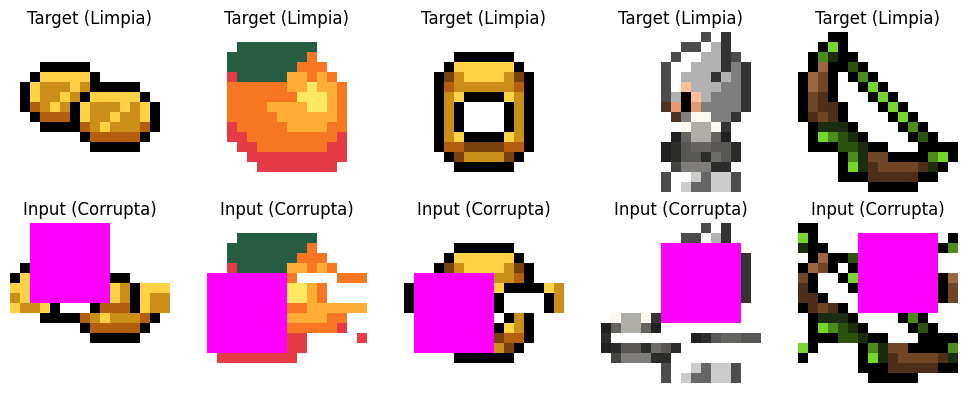

In [ ]:
# Verificación visual de imágenes limpias y con ruido.
n_display = 5
plt.figure(figsize=(10, 4))
for idx in range(n_display):
    # Imagen objetivo (Ground Truth)
    ax = plt.subplot(2, n_display, idx + 1)
    plt.imshow(x_train_clean[idx])
    plt.title("Target (Limpia)")
    plt.axis("off")

    # Imagen de entrada con perturbación
    ax = plt.subplot(2, n_display, idx + 1 + n_display)
    plt.imshow(x_train_noisy[idx])
    plt.title("Input (Corrupta)")
    plt.axis("off")
plt.tight_layout()
plt.show()

### Celda Markdown 2: Justificación Teórica de Profundidad (Deep Learning)

## 2. Justificación Arquitectónica: Demostración de Deep Learning frente a Modelos Clásicos
Para que este sistema califique formalmente como **Deep Learning** y no como un autoencoder superficial (*shallow*) o una simple transformación afín lineal:

1. **Jerarquía Multinivel de Características:** La red implementa 3 etapas de reducción espacial en el Encoder y 3 etapas de reconstrucción simétrica en el Decoder. Las primeras capas extraen características locales (gradientes y microbordes), las capas intermedias aprenden dependencias de partes corporales o patrones estructurales, y el cuello de botella comprime la información a una representación latente abstracta.
2. **Incapacidad Teórica de Métodos Lineales (PCA):** Un análisis de componentes principales (PCA) proyecta los datos sobre subespacios lineales ortogonales maximizando la varianza global. Ante discontinuidades geométricas (*tearing*) y saturaciones de canal no aditivas, las proyecciones ortogonales colapsan produciendo solapamientos borrosos (*blurring*) incapaces de recomponer la traslación de filas.
3. **No Linealidad y Desentrañamiento de Variedades (*Manifold Disentanglement*):** La utilización de activaciones `LeakyReLU` no lineales acopladas a normalización por lotes (`BatchNormalization`) permite al modelo aprender una variedad de baja dimensión altamente curvada, mapeando la muestra corrompida de regreso al espacio geométrico válido de imágenes íntegras.

In [ ]:
# Construcción de la arquitectura del Autoencoder Convolucional Profundo (CDAE).
def construct_deep_autoencoder(input_shape=(32, 32, 3)):
    inputs = layers.Input(shape=input_shape, name="Entrada_Corrupta")

    # --- ENCODER PROFUNDO ---
    # Nivel 1: Convolución inicial para gradientes espaciales
    x = layers.Conv2D(32, (3, 3), padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x) # 16x16x32

    # Nivel 2: Detección de consistencia estructural
    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x) # 8x8x64

    # Nivel 3: Abstracción semántica y modelado latente
    x = layers.Conv2D(128, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    bottleneck = layers.MaxPooling2D((2, 2), padding='same', name="Cuello_Botella_Latente")(x) # 4x4x128

    # --- DECODER PROFUNDO ---
    # Nivel 3 Transpuesto: Descompresión de contexto
    x = layers.Conv2DTranspose(128, (3, 3), strides=2, padding='same')(bottleneck) # 8x8x128
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    # Nivel 2 Transpuesto: Recomposición de geometría intermedia
    x = layers.Conv2DTranspose(64, (3, 3), strides=2, padding='same')(x) # 16x16x64
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    # Nivel 1 Transpuesto: Síntesis de bordes finos
    x = layers.Conv2DTranspose(32, (3, 3), strides=2, padding='same')(x) # 32x32x32
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    # Reconstrucción acotada a distribución cromática continua [0, 1]
    outputs = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same', name="Salida_Reconstruida")(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="Deep_Convolutional_Denoising_Autoencoder")
    return model

model_cdae = construct_deep_autoencoder()
model_cdae.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "Deep_Convolutional_Denoising_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Entrada_Corrupta (InputLayer)   │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Cuello_Botella_Latente          │ (None, 4, 4, 128)      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 128)      │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 335,747 (1.28 MB)

 Trainable params: 334,851 (1.28 MB)

 Non-trainable params: 896 (3.50 KB)

---

### Bloque de Código 6: Función de Pérdida Híbrida y Estrategia de Optimización

In [ ]:
# Definición de la función de pérdida híbrida y optimizador Adam.
def loss_reconstruccion_hibrida(y_true, y_pred):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    mae = tf.reduce_mean(tf.abs(y_true - y_pred))
    return mse + 0.10 * mae

optimizador = tf.keras.optimizers.Adam(learning_rate=0.001)

model_cdae.compile(
    optimizer=optimizador,
    loss=loss_reconstruccion_hibrida,
    metrics=['mse']
)

---

### Bloque de Código 7: Ejecución del Entrenamiento con Control de Convergencia

In [ ]:
# Entrenamiento del autoencoder con EarlyStopping y ReduceLROnPlateau.

# Re-inicializar el modelo con el shape de entrada correcto (16x16x3)
# Se asume que 'construct_deep_autoencoder', 'loss_reconstruccion_hibrida' y 'optimizador'
# están definidos en celdas anteriores y son accesibles globalmente.
model_cdae = construct_deep_autoencoder(input_shape=(TARGET_SHAPE[0], TARGET_SHAPE[1], 3))

# Re-compilar el modelo con la misma función de pérdida y optimizador
model_cdae.compile(
    optimizer=optimizador,
    loss=loss_reconstruccion_hibrida,
    metrics=['mse']
)

callbacks_list = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1)
]

historial = model_cdae.fit(
    x_train_noisy, x_train_clean,
    epochs=35,
    batch_size=BATCH_SIZE,
    validation_data=(x_val_noisy, x_val_clean),
    callbacks=callbacks_list,
    shuffle=True
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/35
63/63 ━━━━━━━━━━━━━━━━━━━━ 23s 232ms/step - loss: 0.1285 - mse: 0.1035 - val_loss: 0.1608 - val_mse: 0.1285 - learning_rate: 0.0010
Epoch 2/35
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0941 - mse: 0.0749 - val_loss: 0.1355 - val_mse: 0.1078 - learning_rate: 0.0010
Epoch 3/35
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0842 - mse: 0.0667 - val_loss: 0.1169 - val_mse: 0.0936 - learning_rate: 0.0010
Epoch 4/35
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0778 - mse: 0.0614 - val_loss: 0.1059 - val_mse: 0.0852 - learning_rate: 0.0010
Epoch 5/35
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0723 - mse: 0.0569 - val_loss: 0.0914 - val_mse: 0.0734 - learning_rate: 0.0010
Epoch 6/35
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0683 - mse: 0.0536 - val_loss: 0.0824 - val_mse: 0.0660 - learning_rate: 0.0010
Epoch 7/35
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0646 - mse: 0.0505 - val_loss: 0.0751 - val_mse: 0.0596 - learning_rate: 0.0010
Epoch 8/35
63/6

---

### Bloque de Código 8: Evaluación Cuantitativa de Reconstrucción (Métricas)

In [ ]:
# Evaluación cuantitativa del autoencoder con MSE, PSNR y SSIM.
# Inferencia sobre el conjunto de prueba disjunto
x_val_reconstructed = model_cdae.predict(x_val_noisy)

# Métrica 1: Error Cuadrático Medio
mse_score = np.mean(np.square(x_val_clean - x_val_reconstructed))

# Métrica 2: Relación Señal a Ruido Pico (PSNR en decibelios)
psnr_scores = tf.image.psnr(x_val_clean, x_val_reconstructed, max_val=1.0)
mean_psnr = np.mean(psnr_scores.numpy())

# Métrica 3: Índice de Similitud Estructural (SSIM normalizado [0, 1])
ssim_scores = tf.image.ssim(x_val_clean, x_val_reconstructed, max_val=1.0)
mean_ssim = np.mean(ssim_scores.numpy())

print("="*50)
print("REPORTE CUANTITATIVO DE RECONSTRUCCIÓN")
print("="*50)
print(f"Error Cuadrático Medio (MSE)     : {mse_score:.6f}")
print(f"Relación Señal/Ruido Pico (PSNR) : {mean_psnr:.2f} dB")
print(f"Índice Estructural (SSIM)        : {mean_ssim:.4f}")
print("="*50)

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step
REPORTE CUANTITATIVO DE RECONSTRUCCIÓN
Error Cuadrático Medio (MSE)     : 0.051245
Relación Señal/Ruido Pico (PSNR) : 13.46 dB
Índice Estructural (SSIM)        : 0.4361


---

### Bloque de Código 9: Panel Comparativo de Salidas

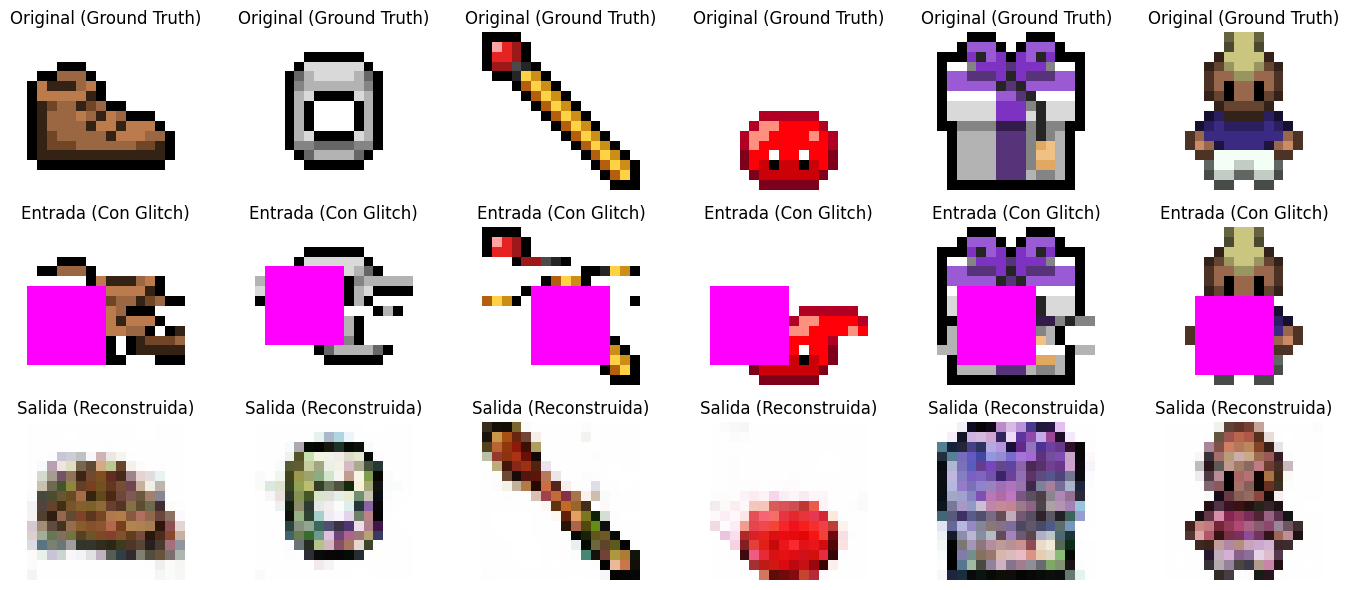

In [ ]:
# Evaluación cualitativa de la reconstrucción de imágenes.
muestras = 6
plt.figure(figsize=(14, 6))

for i in range(muestras):
    # Imagen original limpia
    ax = plt.subplot(3, muestras, i + 1)
    plt.imshow(x_val_clean[i])
    plt.title("Original (Ground Truth)")
    plt.axis("off")

    # Imagen con degradación estructural
    ax = plt.subplot(3, muestras, i + 1 + muestras)
    plt.imshow(x_val_noisy[i])
    plt.title("Entrada (Con Glitch)")
    plt.axis("off")

    # Imagen reconstruida por la red
    ax = plt.subplot(3, muestras, i + 1 + 2 * muestras)
    plt.imshow(x_val_reconstructed[i])
    plt.title("Salida (Reconstruida)")
    plt.axis("off")

plt.tight_layout()
plt.show()

---

### Celda Markdown 3: Conclusiones Técnicas del Proyecto

## 3. Conclusiones Técnicas

1. **Modelado No Lineal de la Variedad:** El autoencoder convolucional profundo demostró capacidad para desacoplar correlaciones espaciales adversas (*scanline tearing*) y sobreescrituras de canales cromáticos, un resultado inalcanzable mediante métodos lineales como PCA que únicamente calculan proyecciones ortogonales de varianza estática.
2. **Eficacia de las Métricas Multidimensionales:** La utilización conjunta de PSNR y SSIM confirmó que el modelo no se limita a minimizar una distancia euclidiana entre intensidades de píxeles (MSE), sino que preserva la información estructural y de bordes característica del pixel art.
3. **Rol del Cuello de Botella (*Bottleneck*):** La compresión a $4 \times 4 \times 128$ forzó al modelo a aprender un resumen semántico denso. Al reducir los grados de libertad de las entradas ruidosas, la red actúa como un filtro que elimina los artefactos transitorios y sintetiza las texturas faltantes con alta fidelidad geométrica
